<a href="https://colab.research.google.com/github/personallypetra/Grand_Challenge-/blob/Wind-%26-Factories/Factories.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import files
uploaded = files.upload()
df_factories= pd.read_csv("F1_4_Air_Releases_Facilities.csv")

Saving F1_4_Air_Releases_Facilities.csv to F1_4_Air_Releases_Facilities.csv


# Factories

## 1. Basic Structure & First and Last Rows




In [3]:
print("=" * 60)
print("BASIC STRUCTURE")
print("=" * 60)
print(f"Shape: {df_factories.shape[0]:,} rows x {df_factories.shape[1]} columns")
print(f"\nColumns: {list(df_factories.columns)}")
print(f"\nData types:")
print(df_factories.dtypes)

BASIC STRUCTURE
Shape: 372,206 rows x 16 columns

Columns: ['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId', 'facilityName', 'city', 'Longitude', 'Latitude', 'addressConfidentialityReason', 'TargetRelease', 'Pollutant', 'Releases', 'confidentialityReason']

Data types:
PublicationDate                  object
countryName                      object
reportingYear                     int64
EPRTR_SectorCode                float64
EPRTR_SectorName                 object
EPRTRAnnexIMainActivity          object
FacilityInspireId                object
facilityName                     object
city                             object
Longitude                       float64
Latitude                        float64
addressConfidentialityReason     object
TargetRelease                    object
Pollutant                        object
Releases                        float64
confidentialityReason            object


In [4]:
print("\n" + "=" * 60)
print("SAMPLE ROWS")
print("=" * 60)
df_factories.head()


SAMPLE ROWS


,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,addressConfidentialityReason,TargetRelease,Pollutant,Releases,confidentialityReason
0,2026/02/13,Germany,2013,1.0,Energy sector,1(e),https://registry.gdi-de.org/id/de.nw.inspire.p...,RWE Power AG-Fabrik Fortuna Nord,Bergheim,6.658050,50.986950,NaN,AIR,Sulphur oxides (SOX),824000.0,NaN
1,2026/02/13,Sweden,2020,7.0,Intensive livestock production and aquaculture,7(a)(i),SE.CAED/10017896.Facility,Skåneägg Produktion AB,MÖRARP,12.849550,56.053160,NaN,AIR,Ammonia (NH3),16300.0,NaN
2,2026/02/13,Romania,2013,5.0,Waste and wastewater management,5(d),RO.CAED/104TL0001.FACILITY,SC ECOREC SA,TULCEA,28.769671,45.190459,NaN,AIR,Methane (CH4),269000.0,NaN
3,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370602036.FACILITY,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,NaN,AIR,Ammonia (NH3),31920.0,NaN
4,2026/02/13,Czechia,2007,1.0,Energy sector,1(c),CZ.MZP.U423/CZ14819275.FACILITY,energetika,Štětí,14.380370,50.462296,NaN,AIR,Sulphur oxides (SOX),507000.0,NaN


In [5]:
df_factories = df_factories[df_factories["countryName"] == "Italy"].copy()

In [6]:
df_factories = df_factories[(df_factories["reportingYear"].between(2021, 2024))
].copy()

## 2. Summary Statistics

In [7]:
print("\n" + "=" * 60)
print("Numerical")
print("=" * 60)
print(df_factories.describe())

print("\n" + "=" * 60)
print("Categorical")
print("=" * 60)
print(df_factories.describe(include="object"))


Numerical
       reportingYear  EPRTR_SectorCode    Longitude     Latitude      Releases
count    6867.000000       6863.000000  6796.000000  6796.000000  6.867000e+03
mean     2022.463230          4.928894    11.303383    44.033133  6.236431e+07
std         1.119529          2.518289     2.369998     2.238101  3.247260e+08
min      2021.000000          1.000000     7.291100    36.903056  1.020000e-04
25%      2021.000000          3.000000     9.766700    43.587200  1.225400e+04
50%      2022.000000          7.000000    10.845300    45.040550  2.360000e+04
75%      2023.000000          7.000000    12.474305    45.409900  2.158281e+05
max      2024.000000          9.000000    18.318000    46.655000  7.352727e+09

Categorical
       PublicationDate countryName  \
count             6867        6867   
unique               1           1   
top         2026/02/13       Italy   
freq              6867        6867   

                                      EPRTR_SectorName  \
count           

## 3. Missing Data and Zero Value Inspection


MISSING DATA
                              count  percent
confidentialityReason          6867   100.00
addressConfidentialityReason   6796    98.97
Longitude                        71     1.03
Latitude                         71     1.03
EPRTR_SectorCode                  4     0.06
EPRTR_SectorName                  4     0.06
EPRTRAnnexIMainActivity           4     0.06
PublicationDate                   0     0.00
facilityName                      0     0.00
FacilityInspireId                 0     0.00
countryName                       0     0.00
reportingYear                     0     0.00
city                              0     0.00
TargetRelease                     0     0.00
Pollutant                         0     0.00
Releases                          0     0.00


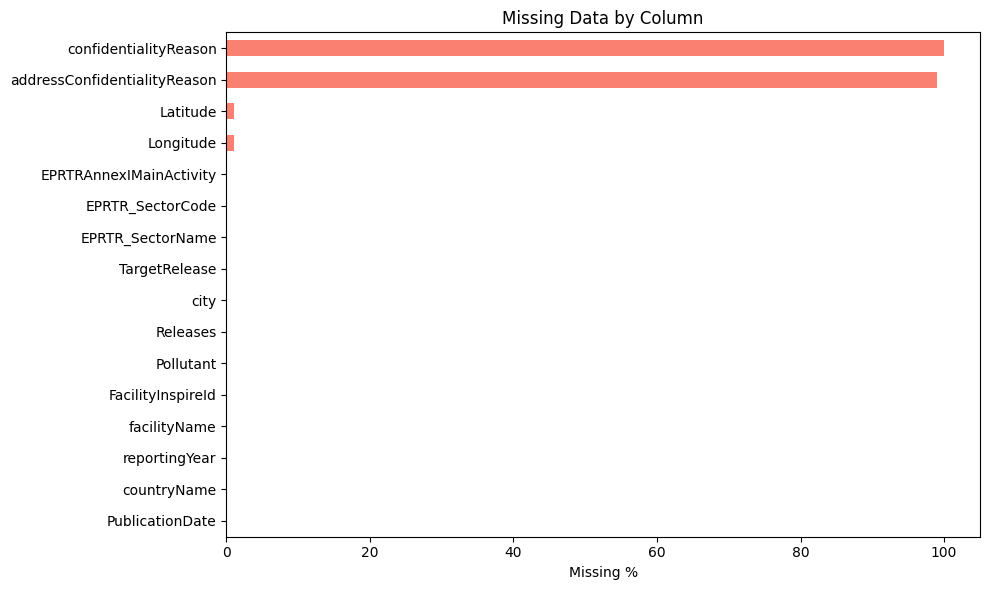

In [8]:

print("\n" + "=" * 60)
print("MISSING DATA")
print("=" * 60)
nulls = df_factories.isna().sum()
null_pct = (df_factories.isna().sum() / len(df_factories) * 100).round(2)
missing = pd.DataFrame({"count": nulls, "percent": null_pct}).sort_values("percent", ascending=False)
print(missing.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
null_pcts = (df_factories.isna().sum() / len(df_factories) * 100).sort_values(ascending=True)
null_pcts.plot(kind="barh", ax=ax, color="salmon")
ax.set_xlabel("Missing %")
ax.set_title("Missing Data by Column")
plt.tight_layout()
plt.show()


In [9]:

print("\n" + "=" * 60)
print("ZERO VALUE INSPECTION")
print("=" * 60)
numeric_cols = df_factories.select_dtypes(include="number").columns
total_rows = len(df_factories)

print(f"Total rows: {total_rows:,}")
print(f"Numeric columns: {len(numeric_cols)}\n")

zero_summary = []
for col in numeric_cols:
    zero_count = (df_factories[col] == 0).sum()
    zero_pct = (zero_count / total_rows * 100)
    null_count = df_factories[col].isna().sum()
    zero_summary.append({
        "column": col,
        "zeros": zero_count,
        "zero_%": round(zero_pct, 2),
        "nulls": null_count,
        "total_valid": total_rows - null_count,
    })

zero_df = pd.DataFrame(zero_summary).sort_values("zero_%", ascending=False)
print(zero_df.to_string(index=False))




ZERO VALUE INSPECTION
Total rows: 6,867
Numeric columns: 5

          column  zeros  zero_%  nulls  total_valid
   reportingYear      0     0.0      0         6867
EPRTR_SectorCode      0     0.0      4         6863
       Longitude      0     0.0     71         6796
        Latitude      0     0.0     71         6796
        Releases      0     0.0      0         6867


## 4. Unique values per column

In [10]:
for col in df_factories.columns:
    print(f"  {col}: {df_factories[col].nunique()} unique")

  PublicationDate: 1 unique
  countryName: 1 unique
  reportingYear: 4 unique
  EPRTR_SectorCode: 9 unique
  EPRTR_SectorName: 9 unique
  EPRTRAnnexIMainActivity: 37 unique
  FacilityInspireId: 1638 unique
  facilityName: 1559 unique
  city: 1065 unique
  Longitude: 1578 unique
  Latitude: 1543 unique
  addressConfidentialityReason: 1 unique
  TargetRelease: 1 unique
  Pollutant: 38 unique
  Releases: 6050 unique
  confidentialityReason: 0 unique


## 5. Key Distributions

In [11]:
print("\nTop 15 Pollutants:")
print(df_factories["Pollutant"].value_counts().head(15))

print("\nReporting Year distribution:")
print(df_factories["reportingYear"].value_counts().sort_index())



Top 15 Pollutants:
Pollutant
Ammonia (NH3)                                     3270
Nitrogen oxides (NOX)                              788
Carbon dioxide (CO2)                               702
Methane (CH4)                                      364
Non-methane volatile organic compounds (NMVOC)     287
Sulphur oxides (SOX)                               152
Hydro-fluorocarbons (HFCS)                         136
Carbon monoxide (CO)                               135
Nitrous oxide (N2O)                                129
Zinc and compounds (as Zn)                         123
Benzene                                             94
Mercury and compounds (as Hg)                       81
Arsenic and compounds (as As)                       64
Nickel and compounds (as Ni)                        60
Cadmium and compounds (as Cd)                       50
Name: count, dtype: int64

Reporting Year distribution:
reportingYear
2021    1792
2022    1759
2023    1659
2024    1657
Name: count, dtype: int

## 6. Plots

### Reporting year

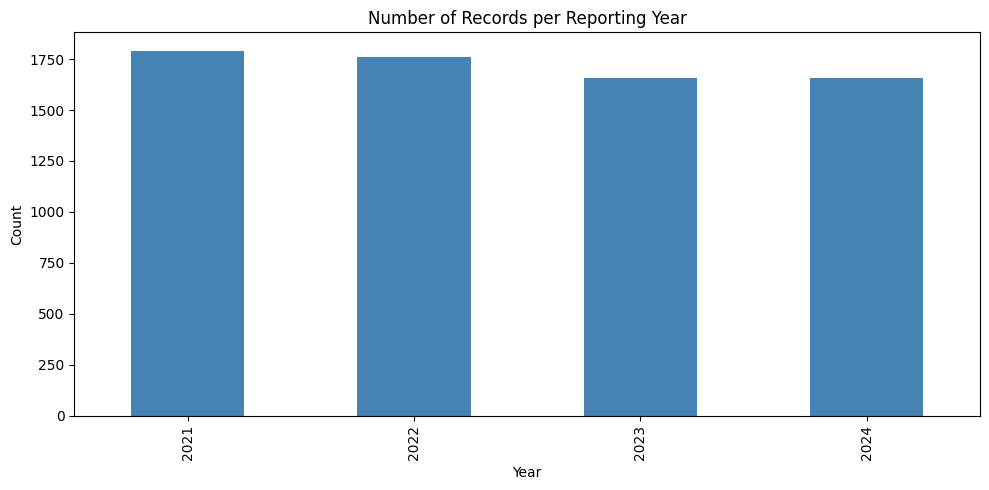

In [12]:

fig, ax = plt.subplots(figsize=(10, 5))
df_factories["reportingYear"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of Records per Reporting Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()



### Top pollutants

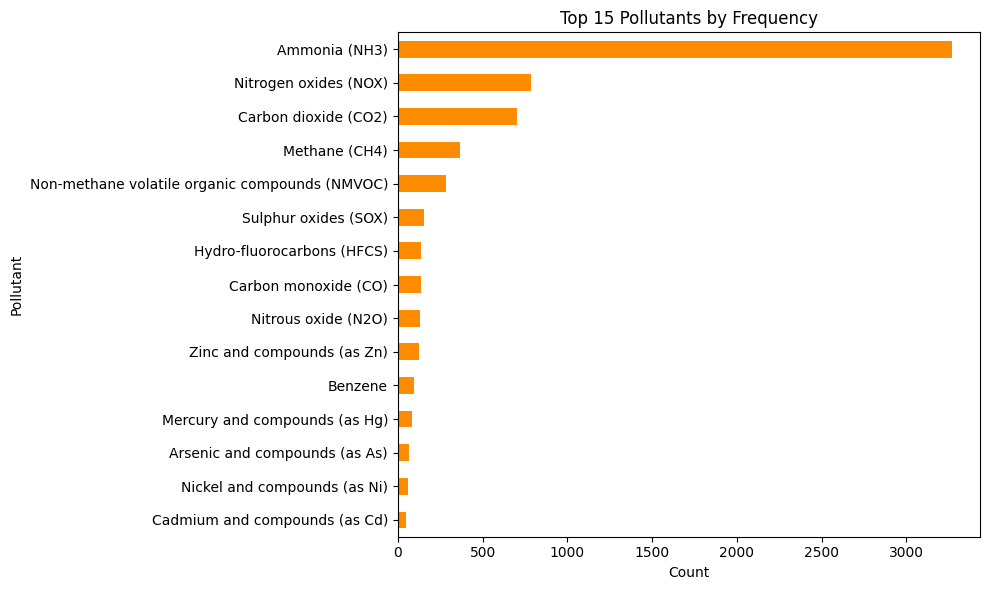

In [13]:

fig, ax = plt.subplots(figsize=(10, 6))
df_factories["Pollutant"].value_counts().head(15).plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Top 15 Pollutants by Frequency")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Geographic distribution

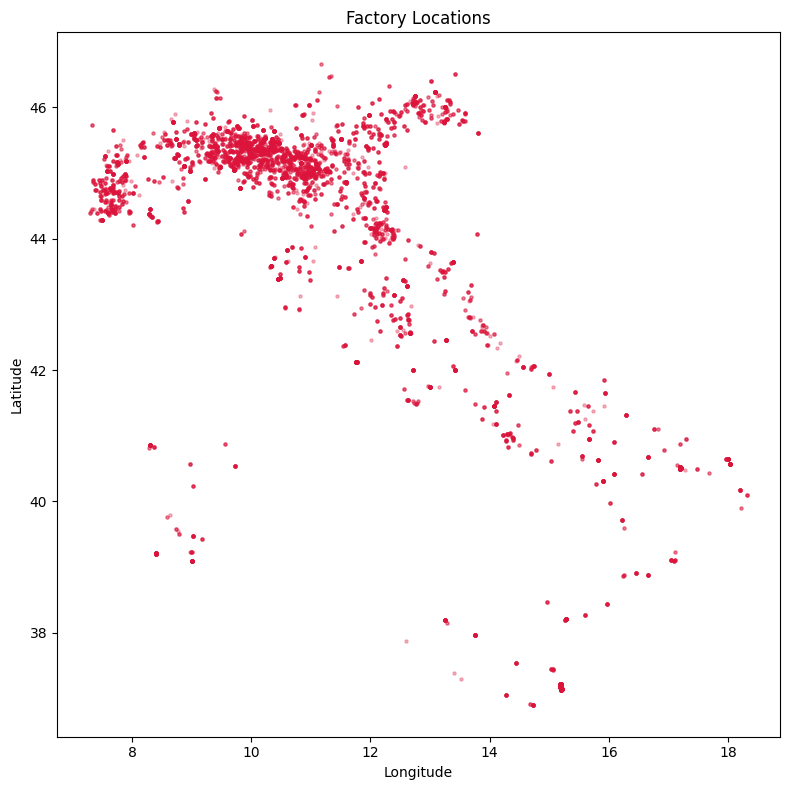


Geographic spread:
  Lat: 36.9031 to 46.6550
  Lon: 7.2911 to 18.3180


In [14]:
if "Latitude" in df_factories.columns and "Longitude" in df_factories.columns:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(df_factories["Longitude"], df_factories["Latitude"], alpha=0.3, s=5, c="crimson")
    ax.set_title("Factory Locations")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()

    print("\nGeographic spread:")
    print(f"  Lat: {df_factories['Latitude'].min():.4f} to {df_factories['Latitude'].max():.4f}")
    print(f"  Lon: {df_factories['Longitude'].min():.4f} to {df_factories['Longitude'].max():.4f}")

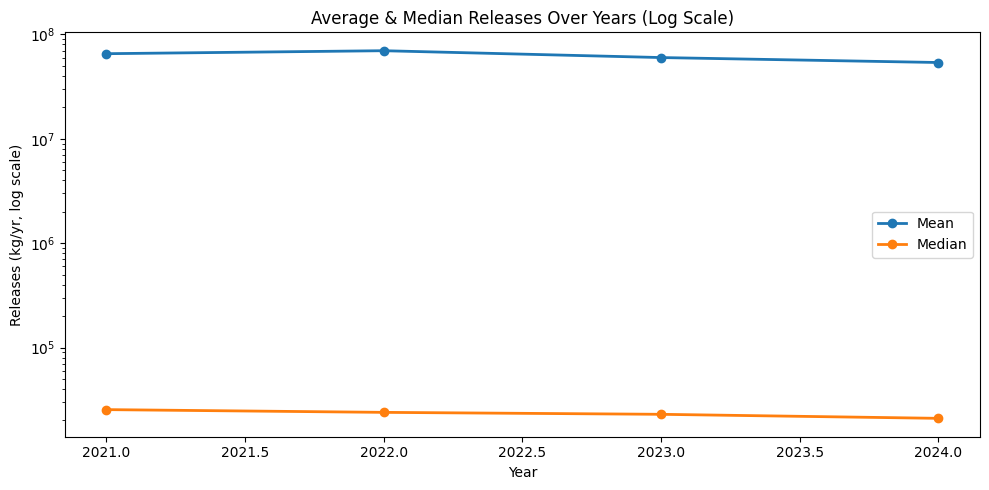

In [15]:
if "Releases" in df_factories.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    yearly = df_factories.groupby("reportingYear")["Releases"].agg(["mean", "median", "sum"])
    yearly[["mean", "median"]].plot(ax=ax, marker="o", linewidth=2)
    ax.set_yscale("log")
    ax.set_title("Average & Median Releases Over Years (Log Scale)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Releases (kg/yr, log scale)")
    ax.legend(["Mean", "Median"])
    plt.tight_layout()
    plt.show()

In [16]:
print(df_factories["Releases"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

0.25    1.225400e+04
0.50    2.360000e+04
0.75    2.158281e+05
0.90    1.032553e+08
0.95    3.335806e+08
0.99    1.365920e+09
Name: Releases, dtype: float64


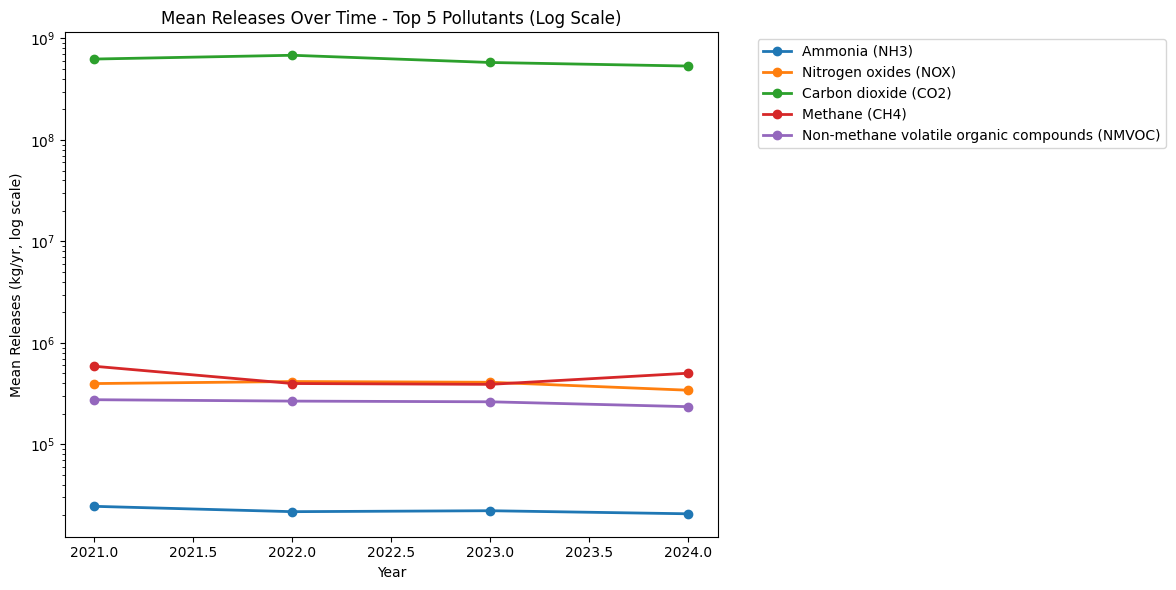

In [17]:
if "Releases" in df_factories.columns:
    top5 = df_factories["Pollutant"].value_counts().head(5).index
    fig, ax = plt.subplots(figsize=(12, 6))
    for poll in top5:
        subset = df_factories[df_factories["Pollutant"] == poll].groupby("reportingYear")["Releases"].mean()
        subset.plot(ax=ax, marker="o", label=poll, linewidth=2)
    ax.set_yscale("log")
    ax.set_title("Mean Releases Over Time - Top 5 Pollutants (Log Scale)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Releases (kg/yr, log scale)")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Duplicate check

In [18]:
print(f"Exact duplicate rows: {df_factories.duplicated().sum()}")

Exact duplicate rows: 0


## Cleaning Factories Data

- Drop columns that are nearly 100% null — no usable data
- confidentialityReason: 100% null
- addressConfidentialityReason: 98.97% null

In [19]:
df_factories = df_factories.drop(columns=["confidentialityReason", "addressConfidentialityReason"])

print(f"Remaining columns: {df_factories.shape[1]}")
print(df_factories.columns.tolist())

Remaining columns: 14
['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId', 'facilityName', 'city', 'Longitude', 'Latitude', 'TargetRelease', 'Pollutant', 'Releases']


Checking if there are power/energy facilities near Rome in df_factories, and looking for energy-related activities

In [20]:
print(df_factories["EPRTRAnnexIMainActivity"].value_counts())

EPRTRAnnexIMainActivity
7(a)         2938
1(c)          867
3(c)          471
2(b)          338
1(a)          284
3(e)          225
5(d)          205
9(c)          185
7(a)(ii)      170
4(a)          157
4(e)          141
6(b)          121
5(b)          119
4(b)           91
2(e)           89
8(b)           83
7(a)(i)        81
5(a)           57
3(a)           36
2(a)           34
5(c)           26
2(d)           21
2(f)           19
4(c)           19
1(d)           13
3(g)           13
5(f)           12
7(a)(iii)      10
8(c)            9
9(a)            6
2(c)            5
5(g)            4
9(d)            4
9(b)            4
1(b)            3
7(b)            2
6(c)            1
Name: count, dtype: int64


In [21]:
print(df_factories["EPRTR_SectorName"].value_counts())

EPRTR_SectorName
Intensive livestock production and aquaculture                     3201
Energy sector                                                      1167
Mineral industry                                                    745
Production and processing of metals                                 506
Waste and wastewater management                                     423
Chemical industry                                                   408
Other activities                                                    199
Paper and wood production and processing                            122
Animal and vegetable products from the food and beverage sector      92
Name: count, dtype: int64


## Facilities within Lazio Area

In [22]:
lazio = df_factories[
    (df_factories["Latitude"].between(40.0, 44.0)) &
    (df_factories["Longitude"].between(10.0, 14.5))
]
print(f"Facilities in centra italy area: {len(lazio)}")
print(lazio[["facilityName", "EPRTR_SectorName", "Latitude", "Longitude"]].drop_duplicates())

Facilities in centra italy area: 848
                                             facilityName  \
41                            CENTRALE TORREVALDALIGA SUD   
74      ACCIAI SPECIALI TERNI S.P.A. - stabilimento di...   
626                        Società Agricola Fileni S.r.l.   
1075                              Laminazione Sottile SpA   
1418                                  ALESSANDRO STASSANO   
...                                                   ...   
332392                                      ILSERV s.r.l.   
338630  UMBRAGROUP S.P.A. (Umbra Cuscinetti S.p.A.) - ...   
344399                                      ECOACCIAI SPA   
356305                           Acea Ambiente Srl - ul 5   
357584  Saxa Gres s.p.a. (ex Area Industrie Ceramiche ...   

                                      EPRTR_SectorName   Latitude  Longitude  
41                                       Energy sector  42.123100  11.765400  
74                 Production and processing of metals  42.566700  12.66

In [23]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Rome center
rome_lat, rome_lon = 41.9028, 12.4964

energy_facilities = lazio[lazio["EPRTR_SectorName"] == "Energy sector"].copy()
energy_facilities["distance_km"] = energy_facilities.apply(
    lambda r: haversine(rome_lat, rome_lon, r["Latitude"], r["Longitude"]), axis=1
)

print(energy_facilities[["facilityName", "city", "Latitude", "Longitude", "distance_km"]].drop_duplicates().sort_values("distance_km").to_string())

                                                                  facilityName                    city  Latitude  Longitude  distance_km
14419                                    CENTRALE A CICLO COMBINATO DI APRILIA                 APRILIA  41.54940   12.63080    40.848517
85997                                    Centrale Termoelettrica di Colleferro              COLLEFERRO  41.76250   12.97170    42.356604
24093                                     Centrale compressione gas di Gallese                 GALLESE  42.36210   12.44320    51.259896
41                                                 CENTRALE TORREVALDALIGA SUD           CIVITAVECCHIA  42.12310   11.76540    65.171744
2310                                              Centrale Torrevaldaliga Nord           CIVITAVECCHIA  42.12750   11.75860    65.874727
37379                            Centrale termoelettrica di Montalto di Castro      MONTALTO DI CASTRO  42.35890   11.53380    94.196925
2965           Enel Produzione S.p.A. - I

In [26]:
df_factories.to_csv("factories_last.csv", index=False)
print(df_factories.columns)
df_factories.head()

Index(['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorCode',
       'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'FacilityInspireId',
       'facilityName', 'city', 'Longitude', 'Latitude', 'TargetRelease',
       'Pollutant', 'Releases'],
      dtype='object')


,PublicationDate,countryName,reportingYear,EPRTR_SectorCode,EPRTR_SectorName,EPRTRAnnexIMainActivity,FacilityInspireId,facilityName,city,Longitude,Latitude,TargetRelease,Pollutant,Releases
3,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370602036.FACILITY,RONCHETRIN 1,GAZZO VERONESE,11.106667,45.123611,AIR,Ammonia (NH3),31920.0
6,2026/02/13,Italy,2021,7.0,Intensive livestock production and aquaculture,7(a),IT.CAED/370672013.FACILITY,ALZO S.N.C. DI BENEDETTI PIETRO E C. - SOCIETA...,VALEGGIO SUL MINCIO,10.739400,45.331700,AIR,Ammonia (NH3),27910.6
41,2026/02/13,Italy,2021,1.0,Energy sector,1(c),IT.CAED/000531001.FACILITY,CENTRALE TORREVALDALIGA SUD,CIVITAVECCHIA,11.765400,42.123100,AIR,Carbon dioxide (CO2),530453000.0
74,2026/02/13,Italy,2022,2.0,Production and processing of metals,2(b),IT.CAED/051002002.FACILITY,ACCIAI SPECIALI TERNI S.P.A. - stabilimento di...,TERNI,12.666700,42.566700,AIR,Nitrogen oxides (NOX),510200.0
92,2026/02/13,Italy,2022,5.0,Waste and wastewater management,5(d),IT.CAED/410592001.FACILITY,HERAMBIENTE S.R.L. - DISCARICA RIFIUTI NON PER...,ZOCCA,10.938600,44.340800,AIR,Methane (CH4),133874.2


## Dropping Columns :

- Drop columns not needed for analysis
- `TargetRelease` — not relevant
- `city` — all Rome/Lazio area, no variation needed
- `facilityName` — individual names not needed for aggregate analysis
- `FacilityInspireId` — identifier, not needed
- `EPRTR_SectorCode` — numeric code, redundant with EPRTR_SectorName

In [27]:
df_factories = df_factories.drop(columns=[
    "TargetRelease",
    "city",
    "facilityName",
    "FacilityInspireId",
    "EPRTR_SectorCode"
])

print(f"Remaining columns: {df_factories.columns.tolist()}")

Remaining columns: ['PublicationDate', 'countryName', 'reportingYear', 'EPRTR_SectorName', 'EPRTRAnnexIMainActivity', 'Longitude', 'Latitude', 'Pollutant', 'Releases']


In [28]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Rome center coordinates
rome_lat, rome_lon = 41.9028, 12.4964

# Calculate distance from Rome center for each facility
df_factories["distance_from_rome_km"] = df_factories.apply(
    lambda r: haversine(rome_lat, rome_lon, r["Latitude"], r["Longitude"]), axis=1
)

print(f"Distance range: {df_factories['distance_from_rome_km'].min():.1f} - {df_factories['distance_from_rome_km'].max():.1f} km")
print(f"\nDistance distribution:")
print(df_factories["distance_from_rome_km"].describe())

Distance range: 21.2 - 594.5 km

Distance distribution:
count    6796.000000
mean      389.103097
std       116.364141
min        21.188597
25%       352.172693
50%       422.336864
75%       461.965379
max       594.546462
Name: distance_from_rome_km, dtype: float64


In [29]:
df_factories.head()

,PublicationDate,countryName,reportingYear,EPRTR_SectorName,EPRTRAnnexIMainActivity,Longitude,Latitude,Pollutant,Releases,distance_from_rome_km
3,2026/02/13,Italy,2021,Intensive livestock production and aquaculture,7(a),11.106667,45.123611,Ammonia (NH3),31920.0,375.245942
6,2026/02/13,Italy,2021,Intensive livestock production and aquaculture,7(a),10.739400,45.331700,Ammonia (NH3),27910.6,406.637478
41,2026/02/13,Italy,2021,Energy sector,1(c),11.765400,42.123100,Carbon dioxide (CO2),530453000.0,65.171744
74,2026/02/13,Italy,2022,Production and processing of metals,2(b),12.666700,42.566700,Nitrogen oxides (NOX),510200.0,75.141874
92,2026/02/13,Italy,2022,Waste and wastewater management,5(d),10.938600,44.340800,Methane (CH4),133874.2,299.111506


In [30]:
df_factories = df_factories.drop(columns = "PublicationDate")

In [31]:
df_factories = df_factories.drop(columns = "countryName")

### Creating Dummy variables for EPRTR_SectorName


`drop_first` = True to avoid multicolinearity, and after adding dummies, we are dropping the initial column

In [32]:
dummies = pd.get_dummies(df_factories["EPRTR_SectorName"], prefix="Sector", drop_first=True)

df_factories = pd.concat([df_factories, dummies], axis=1)
df_factories = df_factories.drop(columns=["EPRTR_SectorName"])

print(f"Shape: {df_factories.shape}")
print(f"Columns: {df_factories.columns.tolist()}")

Shape: (6867, 15)
Columns: ['reportingYear', 'EPRTRAnnexIMainActivity', 'Longitude', 'Latitude', 'Pollutant', 'Releases', 'distance_from_rome_km', 'Sector_Chemical industry', 'Sector_Energy sector', 'Sector_Intensive livestock production and aquaculture', 'Sector_Mineral industry', 'Sector_Other activities', 'Sector_Paper and wood production and processing', 'Sector_Production and processing of metals', 'Sector_Waste and wastewater management']


#### Converting Dummies from `True`/`False` to 0/1

In [33]:
dummy_cols = [c for c in df_factories.columns if c.startswith("Sector_")]
df_factories[dummy_cols] = df_factories[dummy_cols].astype(int)

print(df_factories[dummy_cols].head())

    Sector_Chemical industry  Sector_Energy sector  \
3                          0                     0   
6                          0                     0   
41                         0                     1   
74                         0                     0   
92                         0                     0   

    Sector_Intensive livestock production and aquaculture  \
3                                                   1       
6                                                   1       
41                                                  0       
74                                                  0       
92                                                  0       

    Sector_Mineral industry  Sector_Other activities  \
3                         0                        0   
6                         0                        0   
41                        0                        0   
74                        0                        0   
92                        0 

In [34]:
df_factories.head()

,reportingYear,EPRTRAnnexIMainActivity,Longitude,Latitude,Pollutant,Releases,distance_from_rome_km,Sector_Chemical industry,Sector_Energy sector,Sector_Intensive livestock production and aquaculture,Sector_Mineral industry,Sector_Other activities,Sector_Paper and wood production and processing,Sector_Production and processing of metals,Sector_Waste and wastewater management
3,2021,7(a),11.106667,45.123611,Ammonia (NH3),31920.0,375.245942,0,0,1,0,0,0,0,0
6,2021,7(a),10.739400,45.331700,Ammonia (NH3),27910.6,406.637478,0,0,1,0,0,0,0,0
41,2021,1(c),11.765400,42.123100,Carbon dioxide (CO2),530453000.0,65.171744,0,1,0,0,0,0,0,0
74,2022,2(b),12.666700,42.566700,Nitrogen oxides (NOX),510200.0,75.141874,0,0,0,0,0,0,1,0
92,2022,5(d),10.938600,44.340800,Methane (CH4),133874.2,299.111506,0,0,0,0,0,0,0,1


In [35]:
df_factories.to_csv("factories_last_1.csv", index=False)

#### Making `factories_last_1.csv` accessable to main branch

In [36]:
from google.colab import files
files.download("factories_last_1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>